In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
df = load_breast_cancer()
df

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [3]:
X, y = df.data, df.target

In [4]:
# 80:20 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# StandardScaler 적용
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(455, 30) (114, 30) (455,) (114,)


In [7]:
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

In [8]:
# 은닉층 1개 이상
# 출력층: Sigmoid
class BreastCancerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(30, 64)
        self.fc2=nn.Linear(64, 32)
        self.fc3=nn.Linear(32, 1)
        self.relu=nn.ReLU()
        self.d1=nn.Dropout(0.3)
        self.d2=nn.Dropout(0.2)
        self.sigmoid=nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.d1(x)
        x = self.relu(self.fc2(x))
        x = self.d2(x)
        x = self.sigmoid(self.fc3(x))
        return x

In [9]:
# 손실함수: BCELoss
model = BreastCancerModel()
bceloss = nn.BCELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [10]:
epochs = 100

train_accs, train_losses = [], []
test_accs, test_losses = [], []


for epoch in range(epochs):
    model.train() 
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = bceloss(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item()) # 학습 손실 기록

    model.eval() 
    with torch.no_grad():
        # 학습 데이터 정확도
        train_pred = (outputs > 0.5).float()
        train_acc = (train_pred == y_train).float().mean()
        train_accs.append(train_acc.item())
        
        # 테스트 데이터 손실 및 정확도
        test_outputs = model(X_test)
        test_loss = bceloss(test_outputs, y_test)
        test_losses.append(test_loss.item())
        
        test_pred = (test_outputs > 0.5).float()
        test_acc = (test_pred == y_test).float().mean()
        test_accs.append(test_acc.item())

        if (epoch + 1) % 10 == 0:
            current_train_loss = train_losses[-1]
            current_test_loss = test_losses[-1]
            current_train_acc = train_accs[-1]
            current_test_acc = test_accs[-1]
    
            print(f"Epoch [{epoch+1}/{epochs}]")
            print(f"Train Loss: {current_train_loss:.4f} | Test Loss: {current_test_loss:.4f}")
            print(f"Train Acc: {current_train_acc*100:.2f}% | Test Acc: {current_test_acc*100:.2f}%")
            print("-" * 30)

# 모든 학습이 끝난 후 전체 평균 출력
avg_train_loss = sum(train_losses) / len(train_losses)
avg_test_loss = sum(test_losses) / len(test_losses)
avg_train_acc = sum(train_accs) / len(train_accs)
avg_test_acc = sum(test_accs) / len(test_accs)

print(f"Avg Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")
print(f"Avg Acc: {avg_train_acc*100:.2f}% | Test Acc: {avg_test_acc*100:.2f}%")

Epoch [10/100]
Train Loss: 0.7031 | Test Loss: 0.6957
Train Acc: 42.86% | Test Acc: 44.74%
------------------------------
Epoch [20/100]
Train Loss: 0.6942 | Test Loss: 0.6862
Train Acc: 53.63% | Test Acc: 68.42%
------------------------------
Epoch [30/100]
Train Loss: 0.6866 | Test Loss: 0.6771
Train Acc: 59.34% | Test Acc: 84.21%
------------------------------
Epoch [40/100]
Train Loss: 0.6755 | Test Loss: 0.6679
Train Acc: 70.33% | Test Acc: 88.60%
------------------------------
Epoch [50/100]
Train Loss: 0.6672 | Test Loss: 0.6585
Train Acc: 77.14% | Test Acc: 93.86%
------------------------------
Epoch [60/100]
Train Loss: 0.6579 | Test Loss: 0.6485
Train Acc: 80.66% | Test Acc: 96.49%
------------------------------
Epoch [70/100]
Train Loss: 0.6475 | Test Loss: 0.6378
Train Acc: 83.30% | Test Acc: 96.49%
------------------------------
Epoch [80/100]
Train Loss: 0.6356 | Test Loss: 0.6262
Train Acc: 86.37% | Test Acc: 96.49%
------------------------------
Epoch [90/100]
Train Los

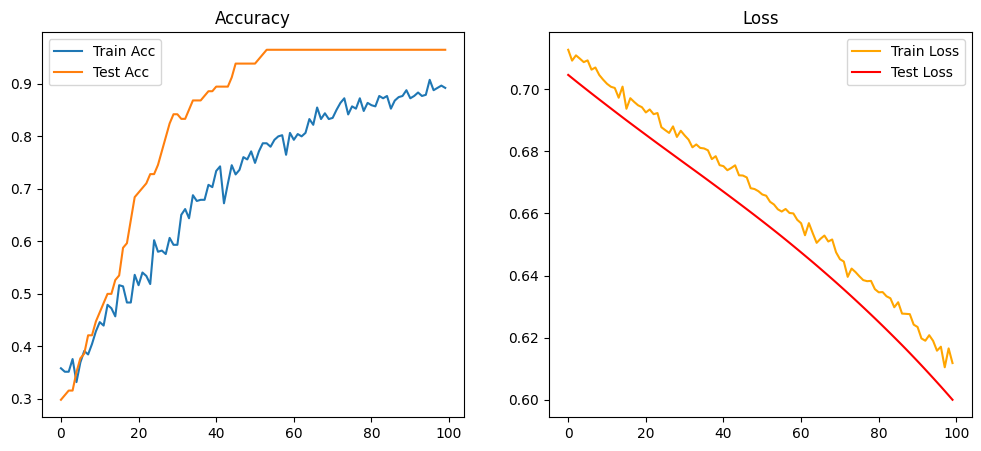

In [11]:
# 시각화 (정확도 & 손실률)
plt.figure(figsize=(12, 5))

# 정확도 그래프
plt.subplot(1, 2, 1)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Test Acc')
plt.title('Accuracy')
plt.legend()

# 손실률 그래프
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss', color='orange')
plt.plot(test_losses, label='Test Loss', color='red')
plt.title('Loss')
plt.legend()

plt.show()